<a href="https://colab.research.google.com/github/ontherays/Shallow-and-Deep-Learning-Model-Comparison-/blob/main/Machine%20Learning%20Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

adult_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
col_names = [
    'age','workclass','fnlwgt','education','education-num','marital-status','occupation',
    'relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','income'
]

df_adult = pd.read_csv(adult_url, names=col_names, skipinitialspace=True)

df_adult.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df = df_adult.copy()

# Remove rows with '?'
df = df.replace('?', pd.NA).dropna()

# Encode categorical values
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Split into X and y
X = df.drop('income', axis=1)
y = df['income']

X.shape, y.shape


((30162, 14), (30162,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((24129, 14), (6033, 14))

In [ ]:
import numpy as np

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Shallow neural network (2 hidden layers)
shallow_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

shallow_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

shallow_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_shallow = shallow_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5077 - loss: 4364.7065 - val_accuracy: 0.2516 - val_loss: 34.5687
Epoch 2/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6765 - loss: 26.7583 - val_accuracy: 0.7866 - val_loss: 22.1547
Epoch 3/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6879 - loss: 25.9696 - val_accuracy: 0.7874 - val_loss: 44.8639
Epoch 4/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6621 - loss: 33.1245 - val_accuracy: 0.7874 - val_loss: 14.3126
Epoch 5/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6918 - loss: 21.1096 - val_accuracy: 0.6191 - val_loss: 5.0918
Epoch 6/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6706 - loss: 27.6798 - val_accuracy: 0.7762 - val_loss: 51.0546
Epoch 7/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6767 - loss: 28.0014 - val_accuracy: 0.7772 - val_loss: 35.3914
Epoch 8/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6766 - loss: 29.2097 - 

In [ ]:
test_loss, test_accuracy = shallow_model.evaluate(X_test, y_test, verbose=0)
print("Shallow Model Test Accuracy:", test_accuracy)


Shallow Model Test Accuracy: 0.781369149684906


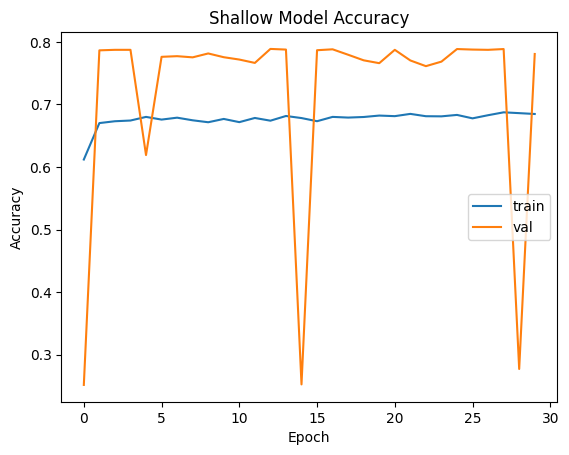

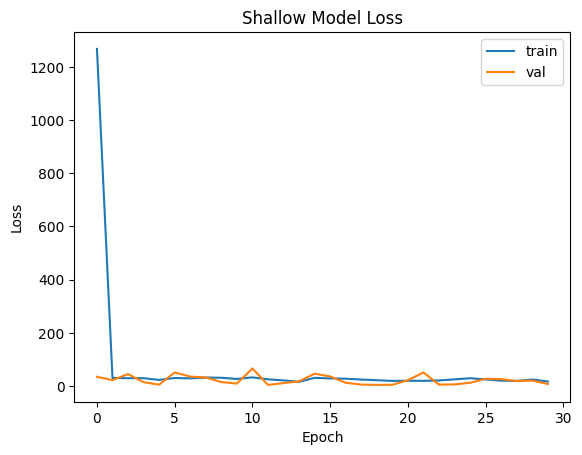

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history_shallow.history['accuracy'])
plt.plot(history_shallow.history['val_accuracy'])
plt.title('Shallow Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.show()

# Plot training & validation loss
plt.plot(history_shallow.history['loss'])
plt.plot(history_shallow.history['val_loss'])
plt.title('Shallow Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.show()


In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras import Sequential

deep_model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(16, activation='relu'),
    BatchNormalization(),

    Dense(16, activation='relu'),
    BatchNormalization(),

    Dense(8, activation='relu'),
    BatchNormalization(),

    Dropout(0.2),  # Reduces overfitting

    Dense(1, activation='sigmoid')   # Output layer
])

deep_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,129 (39.57 KB)

 Trainable params: 9,665 (37.75 KB)

 Non-trainable params: 464 (1.81 KB)

In [ ]:
history_deep = deep_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5959 - loss: 0.6933 - val_accuracy: 0.7924 - val_loss: 0.5425
Epoch 2/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7681 - loss: 0.5424 - val_accuracy: 0.7717 - val_loss: 0.5355
Epoch 3/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7860 - loss: 0.5247 - val_accuracy: 0.7930 - val_loss: 0.5133
Epoch 4/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7893 - loss: 0.5189 - val_accuracy: 0.6585 - val_loss: 0.6194
Epoch 5/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7887 - loss: 0.5120 - val_accuracy: 0.7953 - val_loss: 0.5001
Epoch 6/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7837 - loss: 0.5187 - val_accuracy: 0.7940 - val_loss: 0.5455
Epoch 7/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7902 - loss: 0.5112 - val_accuracy: 0.7835 - val_loss: 0.5250
Epoch 8/40
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7906 - loss: 0.4963 - val_accuracy: 0.

In [ ]:
test_loss_d, test_accuracy_d = deep_model.evaluate(X_test, y_test, verbose=0)
print("Deep Model Test Accuracy:", test_accuracy_d)


Deep Model Test Accuracy: 0.7676114439964294


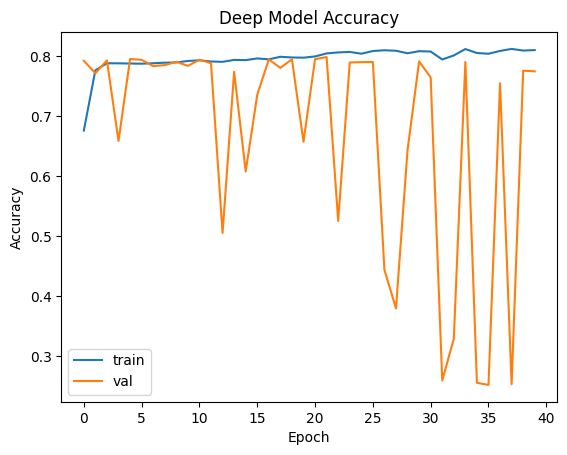

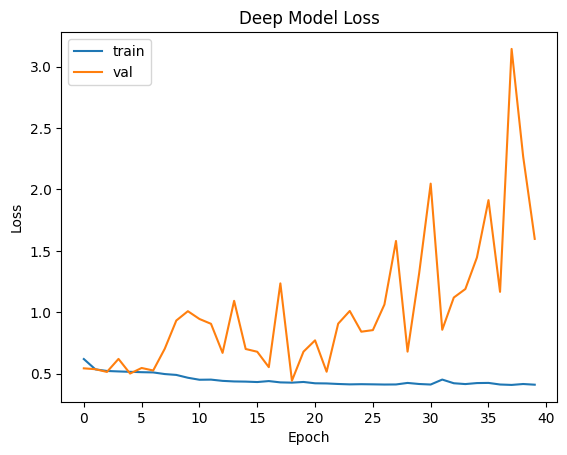

In [ ]:
# Accuracy curves
plt.plot(history_deep.history['accuracy'])
plt.plot(history_deep.history['val_accuracy'])
plt.title('Deep Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.show()

# Loss curves
plt.plot(history_deep.history['loss'])
plt.plot(history_deep.history['val_loss'])
plt.title('Deep Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Build a deep model using sigmoid (this causes vanishing gradient)
def build_vanishing_model(input_dim):
    model = tf.keras.Sequential()
    for _ in range(10):   # 10 layers = enough depth to show the problem
        model.add(tf.keras.layers.Dense(64, activation="sigmoid"))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    return model

model_vanish = build_vanishing_model(X_train.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.BinaryCrossentropy()

gradient_norms = []

# Custom training loop to capture gradients
for epoch in range(3):  # small epochs just to observe
    print(f"\nEPOCH {epoch+1}")
    for step, (x_batch, y_batch) in enumerate(zip(X_train, y_train)):
        x_batch = x_batch.reshape(1, -1)
        y_batch = y_batch.reshape(1, -1)

        with tf.GradientTape() as tape:
            preds = model_vanish(x_batch, training=True)
            loss = loss_fn(y_batch, preds)

        grads = tape.gradient(loss, model_vanish.trainable_weights)

        # Compute mean gradient magnitude
        grad_norm = np.mean([np.mean(np.abs(g.numpy())) for g in grads if g is not None])
        gradient_norms.append(grad_norm)

        if step % 5000 == 0:
            print(f"Step {step}: gradient norm = {grad_norm}")

# Plot gradient norms
plt.figure(figsize=(10,5))
plt.plot(gradient_norms)
plt.title("Gradient Norms Over Training Steps")
plt.xlabel("Training Step")
plt.ylabel("Mean Gradient Magnitude")
plt.show()



EPOCH 1
Step 0: gradient norm = 0.04000382125377655
Step 5000: gradient norm = 0.04000382125377655
Step 10000: gradient norm = 0.04000382125377655
Step 15000: gradient norm = 0.04000382125377655
Step 20000: gradient norm = 0.04000382125377655

EPOCH 2
Step 0: gradient norm = 0.04000382125377655


KeyboardInterrupt: 


EPOCH 1
Epoch 1 finished

EPOCH 2
Epoch 2 finished

EPOCH 3
Epoch 3 finished


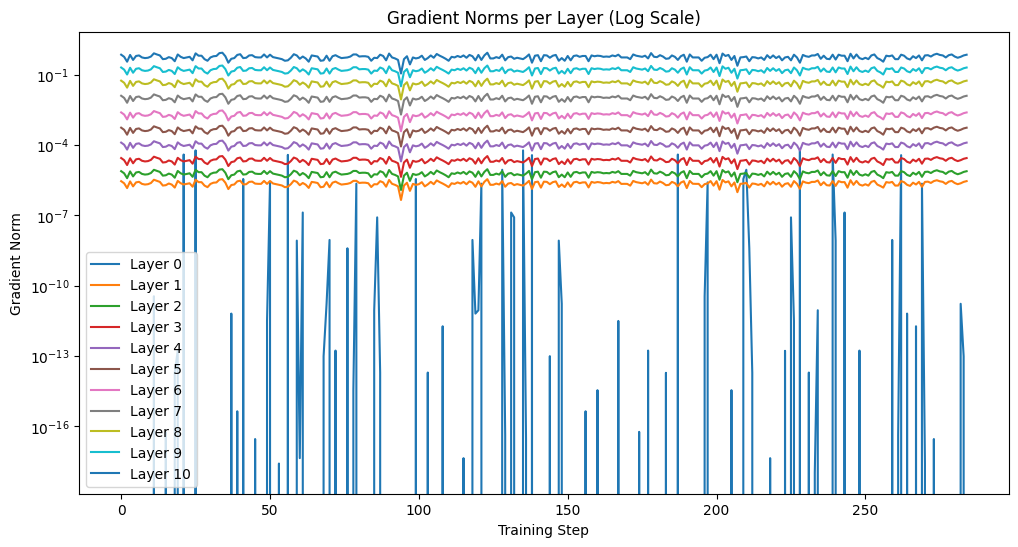

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Deep model with sigmoid activation
def build_vanishing_model(input_dim):
    model = tf.keras.Sequential()
    for _ in range(10):
        model.add(tf.keras.layers.Dense(64, activation="sigmoid"))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    return model

model_vanish = build_vanishing_model(X_train.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.BinaryCrossentropy()

batch_size = 256
gradient_history = {i: [] for i in range(len(model_vanish.layers))}

# Custom training loop for minibatch gradient extraction
for epoch in range(3):
    print(f"\nEPOCH {epoch+1}")
    indices = np.arange(len(X_train))
    np.random.shuffle(indices)

    for step in range(0, len(X_train), batch_size):
        batch_idx = indices[step:step + batch_size]
        x_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]

        with tf.GradientTape() as tape:
            preds = model_vanish(x_batch, training=True)
            loss = loss_fn(y_batch, preds)

        grads = tape.gradient(loss, model_vanish.trainable_weights)

        # Track gradient norms per layer
        w_idx = 0
        for layer_i, layer in enumerate(model_vanish.layers):
            layer_grads = grads[w_idx]
            w_idx += 2 if isinstance(layer, tf.keras.layers.Dense) else 0

            if layer_grads is not None:
                gradient_norm = tf.norm(layer_grads).numpy()
                gradient_history[layer_i].append(gradient_norm)

    print(f"Epoch {epoch+1} finished")

# Plot gradient norms of each layer
plt.figure(figsize=(12,6))
for layer_i, grads in gradient_history.items():
    plt.plot(grads, label=f"Layer {layer_i}")

plt.yscale("log")
plt.title("Gradient Norms per Layer (Log Scale)")
plt.xlabel("Training Step")
plt.ylabel("Gradient Norm")
plt.legend()
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np

vanish_model = tf.keras.Sequential()
for _ in range(10):
    vanish_model.add(tf.keras.layers.Dense(64, activation="sigmoid"))
vanish_model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

x_batch = X_train[:256]
y_batch = y_train[:256]

with tf.GradientTape() as tape:
    preds = vanish_model(x_batch)
    loss = tf.keras.losses.binary_crossentropy(y_batch[..., tf.newaxis], preds) # Reshape y_batch

grads = tape.gradient(loss, vanish_model.trainable_weights)

print("Gradient norms per layer:")
for i in range(0, len(grads), 2):
    print(f"Layer {i//2}: {tf.norm(grads[i]).numpy()}")

ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(256,), output.shape=(256, 1)

In [ ]:
import tensorflow as tf
import numpy as np

vanish_model = tf.keras.Sequential()
for _ in range(10):
    vanish_model.add(tf.keras.layers.Dense(64, activation="sigmoid"))
vanish_model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

x_batch = X_train[:256]
y_batch = y_train[:256]

with tf.GradientTape() as tape:
    preds = vanish_model(x_batch)
    loss = tf.keras.losses.binary_crossentropy(y_batch[..., tf.newaxis], preds) # Reshape y_batch

grads = tape.gradient(loss, vanish_model.trainable_weights)

print("Gradient norms per layer:")
for i in range(0, len(grads), 2):
    print(f"Layer {i//2}: {tf.norm(grads[i]).numpy()}")

Gradient norms per layer:
Layer 0: 0.0
Layer 1: 0.0016544534591957927
Layer 2: 0.005400686524808407
Layer 3: 0.021596502512693405
Layer 4: 0.09669112414121628
Layer 5: 0.36892640590667725
Layer 6: 1.5510891675949097
Layer 7: 6.675374984741211
Layer 8: 30.427181243896484
Layer 9: 156.14828491210938
Layer 10: 396.54302978515625


In [ ]:
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, X_test.shape, y_train.shape


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28), (10000, 28, 28), (60000,))

In [ ]:
import numpy as np

# Flatten the images
X_train = X_train.reshape((60000, 784)).astype("float32") / 255.0
X_test = X_test.reshape((10000, 784)).astype("float32") / 255.0

X_train.shape, X_test.shape


((60000, 784), (10000, 784))

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

y_train_cat.shape


(60000, 10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

shallow_model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    BatchNormalization(),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(10, activation='softmax')
])

shallow_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

shallow_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
history_shallow = shallow_model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8477 - loss: 0.5119 - val_accuracy: 0.9688 - val_loss: 0.1205
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9695 - loss: 0.1080 - val_accuracy: 0.9730 - val_loss: 0.0929
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9778 - loss: 0.0737 - val_accuracy: 0.9785 - val_loss: 0.0761
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9852 - loss: 0.0513 - val_accuracy: 0.9762 - val_loss: 0.0832
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9880 - loss: 0.0403 - val_accuracy: 0.9772 - val_loss: 0.0844
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9909 - loss: 0.0298 - val_accuracy: 0.9790 - val_loss: 0.0780
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9920 - loss: 0.0258 - val_accuracy: 0.9800 - val_loss: 0.0833
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = shallow_model.evaluate(X_test, y_test_cat, verbose=0)
print("Shallow Model Test Accuracy:", test_acc)


Shallow Model Test Accuracy: 0.9771000146865845


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

deep_model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    BatchNormalization(),

    Dense(256, activation='relu'),
    BatchNormalization(),

    Dense(256, activation='relu'),
    BatchNormalization(),

    Dense(128, activation='relu'),
    BatchNormalization(),

    Dense(128, activation='relu'),
    BatchNormalization(),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dropout(0.3),

    Dense(10, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,618 (2.54 MB)

 Trainable params: 661,866 (2.52 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
history_deep = deep_model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.7903 - loss: 0.7257 - val_accuracy: 0.9630 - val_loss: 0.1240
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9602 - loss: 0.1507 - val_accuracy: 0.9675 - val_loss: 0.1109
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9708 - loss: 0.1070 - val_accuracy: 0.9728 - val_loss: 0.0944
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9774 - loss: 0.0818 - val_accuracy: 0.9735 - val_loss: 0.0977
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9784 - loss: 0.0777 - val_accuracy: 0.9770 - val_loss: 0.0827
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9828 - loss: 0.0594 - val_accuracy: 0.9770 - val_loss: 0.0826
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9847 - loss: 0.0518 - val_accuracy: 0.9765 - val_loss: 0.0912
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9853 - loss: 0.0508 - 

In [ ]:
test_loss, test_acc = deep_model.evaluate(X_test, y_test_cat, verbose=0)
print("Deep Model Test Accuracy:", test_acc)


Deep Model Test Accuracy: 0.9828000068664551


In [ ]:
print("history_shallow exists:", 'history_shallow' in globals())
print("history_deep exists:", 'history_deep' in globals())

history_shallow exists: True
history_deep exists: True


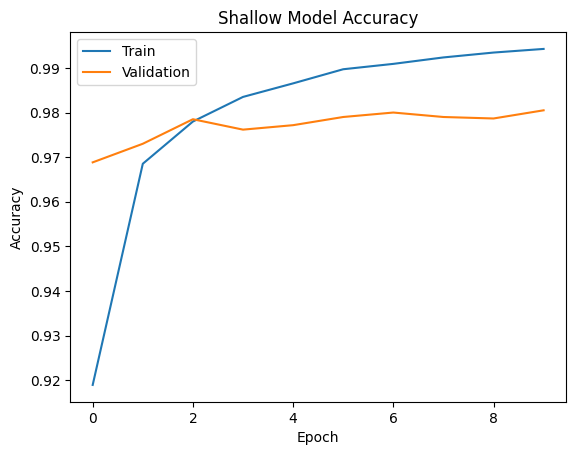

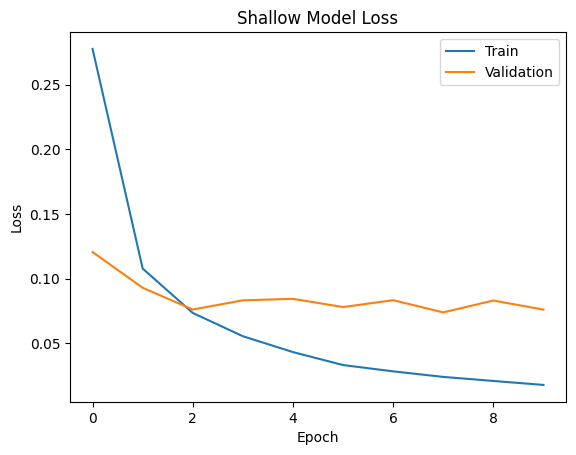

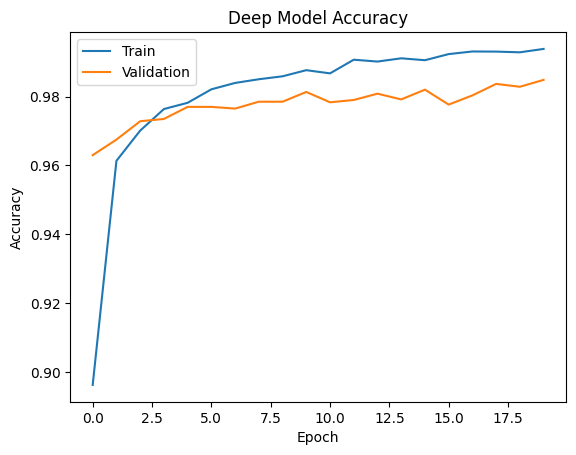

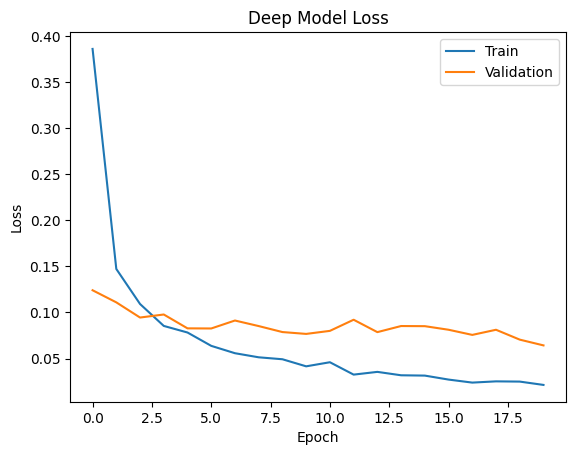

In [ ]:
import matplotlib.pyplot as plt

# --- SHALLOW ACCURACY ---
plt.figure()
plt.plot(history_shallow.history['accuracy'])
plt.plot(history_shallow.history['val_accuracy'])
plt.title('Shallow Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# --- SHALLOW LOSS ---
plt.figure()
plt.plot(history_shallow.history['loss'])
plt.plot(history_shallow.history['val_loss'])
plt.title('Shallow Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# --- DEEP ACCURACY ---
plt.figure()
plt.plot(history_deep.history['accuracy'])
plt.plot(history_deep.history['val_accuracy'])
plt.title('Deep Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# --- DEEP LOSS ---
plt.figure()
plt.plot(history_deep.history['loss'])
plt.plot(history_deep.history['val_loss'])
plt.title('Deep Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
history_shallow

In [ ]:
history_adult

NameError: name 'history_adult' is not defined

In [ ]:
print("Type of history_shallow (adult dataset):", type(history_shallow))
print("Type of history_deep (adult dataset):", type(history_deep))

Type of history_shallow (adult dataset): <class 'keras.src.callbacks.history.History'>
Type of history_deep (adult dataset): <class 'keras.src.callbacks.history.History'>


In [ ]:
# Rename history variables for adult dataset for clarity
history_adult_shallow = history_shallow
history_adult_deep = history_deep

print("history_adult_shallow created and assigned.")
print("history_adult_deep created and assigned.")

history_adult_shallow created and assigned.
history_adult_deep created and assigned.


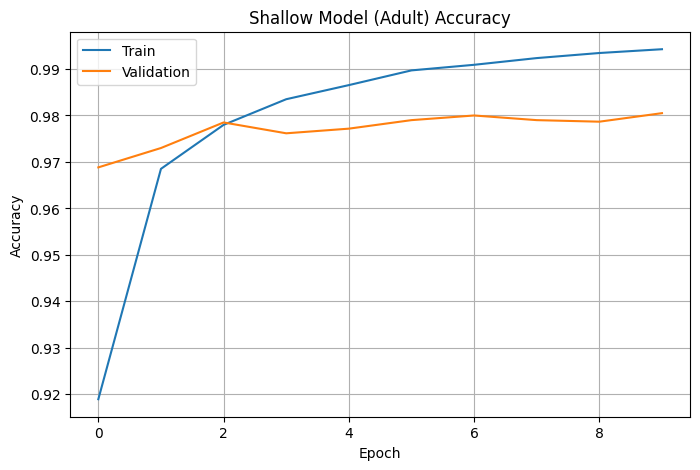

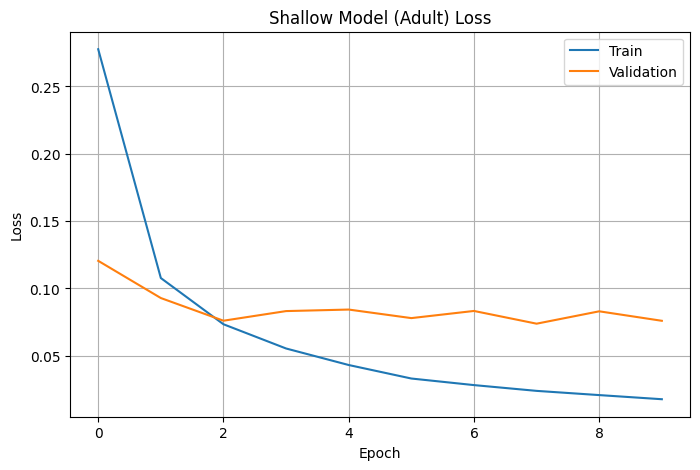

In [ ]:
import matplotlib.pyplot as plt

# --- SHALLOW MODEL (ADULT DATASET) ACCURACY ---
plt.figure(figsize=(8, 5))
plt.plot(history_adult_shallow.history['accuracy'])
plt.plot(history_adult_shallow.history['val_accuracy'])
plt.title('Shallow Model (Adult) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()

# --- SHALLOW MODEL (ADULT DATASET) LOSS ---
plt.figure(figsize=(8, 5))
plt.plot(history_adult_shallow.history['loss'])
plt.plot(history_adult_shallow.history['val_loss'])
plt.title('Shallow Model (Adult) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()

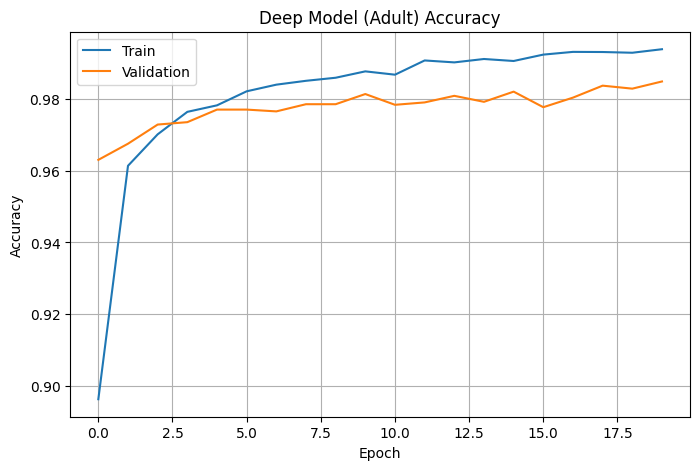

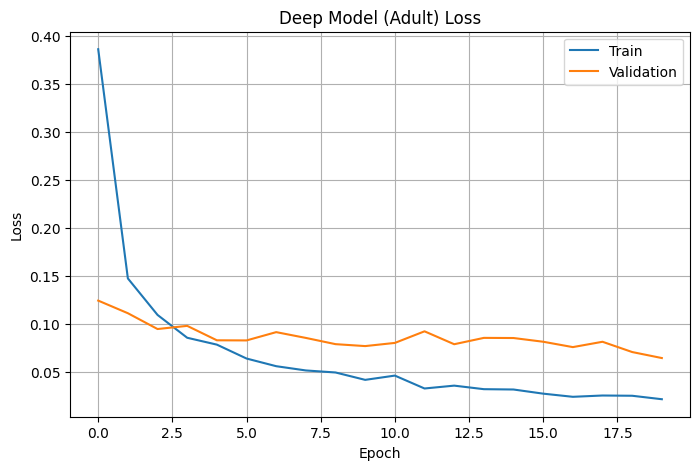

In [ ]:
import matplotlib.pyplot as plt

# --- DEEP MODEL (ADULT DATASET) ACCURACY ---
plt.figure(figsize=(8, 5))
plt.plot(history_adult_deep.history['accuracy'])
plt.plot(history_adult_deep.history['val_accuracy'])
plt.title('Deep Model (Adult) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()

# --- DEEP MODEL (ADULT DATASET) LOSS ---
plt.figure(figsize=(8, 5))
plt.plot(history_adult_deep.history['loss'])
plt.plot(history_adult_deep.history['val_loss'])
plt.title('Deep Model (Adult) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()